In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.incertidumbres import (
    graficar_imagen,
    crear_dataframe_incertidumbre,
    plot_incertidumbres,
    plot_combinado
)
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
import pickle
import pandas as pd
import tensorflow as tf

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model_name = "ResNet152V2" #"MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"../models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
with open(f'../models/label_encoder_{model_name}.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

In [14]:
preprocessor = ImagePreprocessor(label_encoder=label_encoder)
data = preprocessor.load_data_from_directory("../src/data/images_test/images_spectograms")
data.head()

,label,image_path
0,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/121142_13.jpeg
1,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/511703_5.jpeg
2,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/461011_0.jpeg
3,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/621780_9.jpeg
4,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/428484_0.jpeg


In [5]:
sp_metrics = pd.read_csv("../models/metrics_resnet.csv")

In [6]:
sp = data[data["label"] == "Lathrotriccus euleri"]
sp.sample(6)

,label,image_path
14704,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/646464_4.jpeg
14686,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/738627_0.jpeg
14657,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/247442_4.jpeg
14708,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/608933_8.jpeg
14692,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/272813_0.jpeg
14677,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/224880_7.jpeg


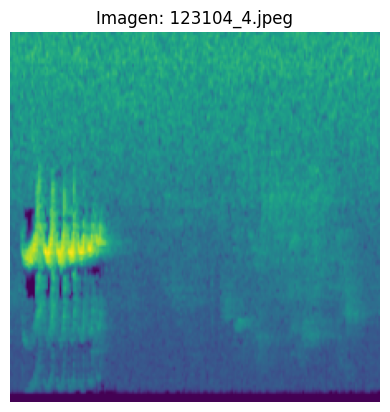

In [7]:
graficar_imagen(sp['image_path'].iloc[32])

# **Volatinia jacarina**

In [8]:
sp = data[data["label"] == "Volatinia jacarina"]
muestra = sp[sp['image_path'].str.contains('146774_0.jpeg')]
muestra

,label,image_path
31431,Volatinia jacarina,../src/data/images_test/images_spectograms/Volatinia jacarina/146774_0.jpeg


In [9]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Volatinia jacarina)


2025-10-23 21:40:32.791226: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [12:45<00:00, 765.72s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Volatinia jacarina,651,651,651,0.91,1,1,0.97
1,Volatinia jacarina,651,651,651,0.90,1,1,0.97
2,Volatinia jacarina,651,651,651,0.92,1,1,0.97
3,Volatinia jacarina,651,651,651,0.85,1,1,0.97
4,Volatinia jacarina,651,651,651,0.88,1,1,0.97


In [10]:
Volatinia_jacarina = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [11]:
Volatinia_jacarina

,prediccion_mc,proportion
0,651,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


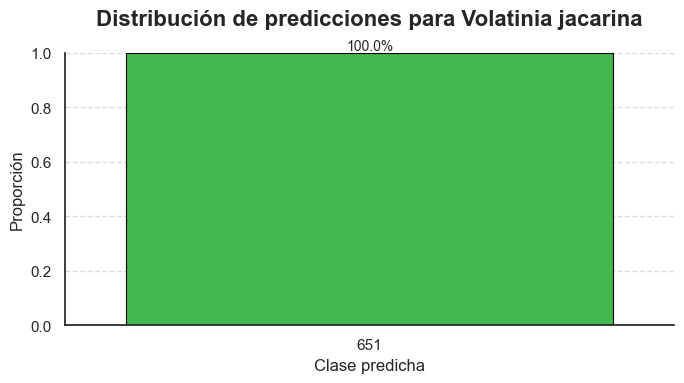

In [12]:
plot_incertidumbres(Volatinia_jacarina, 651, "Volatinia jacarina")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


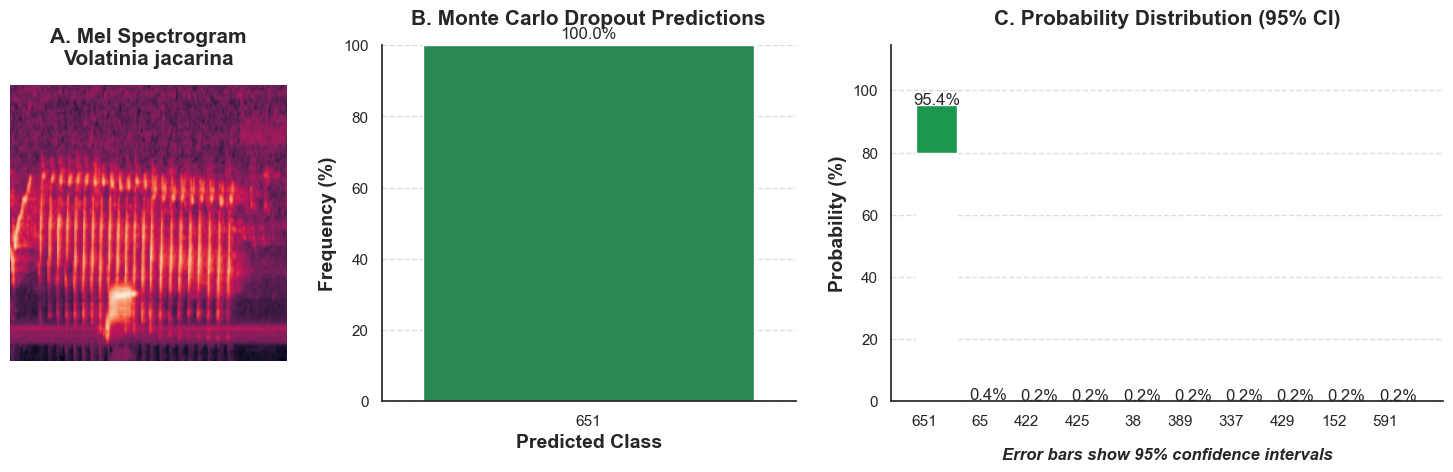

In [13]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Volatinia_jacarina,
    label=651,
    titulo_especie="Volatinia jacarina",
    predicted_probabilities=resultados["Volatinia jacarina"]["predicted_probabilities"],
    etiqueta_real=resultados["Volatinia jacarina"]["clase_real"][0]
)

In [11]:
labels_frecuencia = [651, 65, 422, 425, 38, 389, 337, 429, 152, 591]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 651: Volatinia jacarina
2 - 65: Cantorchilus leucotis
3 - 422: Pheugopedius fasciatoventris
4 - 425: Pheugopedius rutilus
5 - 38: Attila cinnamomeus
6 - 389: Myrmotherula menetriesii
7 - 337: Milvago chimachima
8 - 429: Phlegopsis nigromaculata
9 - 152: Daptrius ater
10 - 591: Tersina viridis


# **Legatus leucophaius**

In [15]:
sp = data[data["label"] == "Legatus leucophaius"]
muestra = sp[sp['image_path'].str.contains('275478_4.jpeg')]
muestra

,label,image_path
14744,Legatus leucophaius,../src/data/images_test/images_spectograms/Legatus leucophaius/275478_4.jpeg


In [16]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Legatus leucophaius)


2025-10-23 21:52:18.327453: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [11:45<00:00, 705.21s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Legatus leucophaius,301,301,301,0.85,1,1,1.53
1,Legatus leucophaius,301,301,301,0.87,1,1,1.53
2,Legatus leucophaius,301,301,301,0.76,1,1,1.53
3,Legatus leucophaius,301,301,301,0.84,1,1,1.53
4,Legatus leucophaius,301,301,301,0.86,1,1,1.53


In [17]:
Legatus_leucophaius = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [18]:
Legatus_leucophaius

,prediccion_mc,proportion
0,301,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


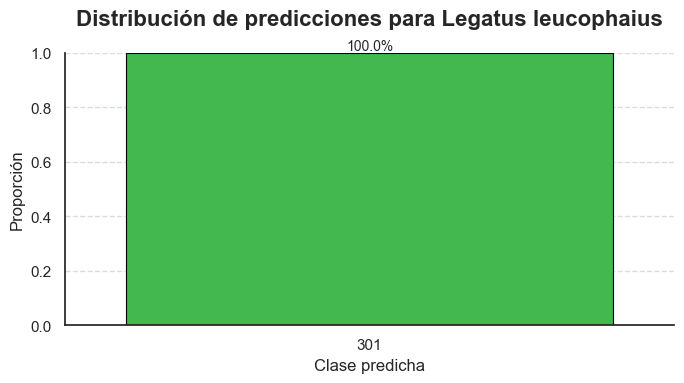

In [19]:
plot_incertidumbres(Legatus_leucophaius, 301, "Legatus leucophaius")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


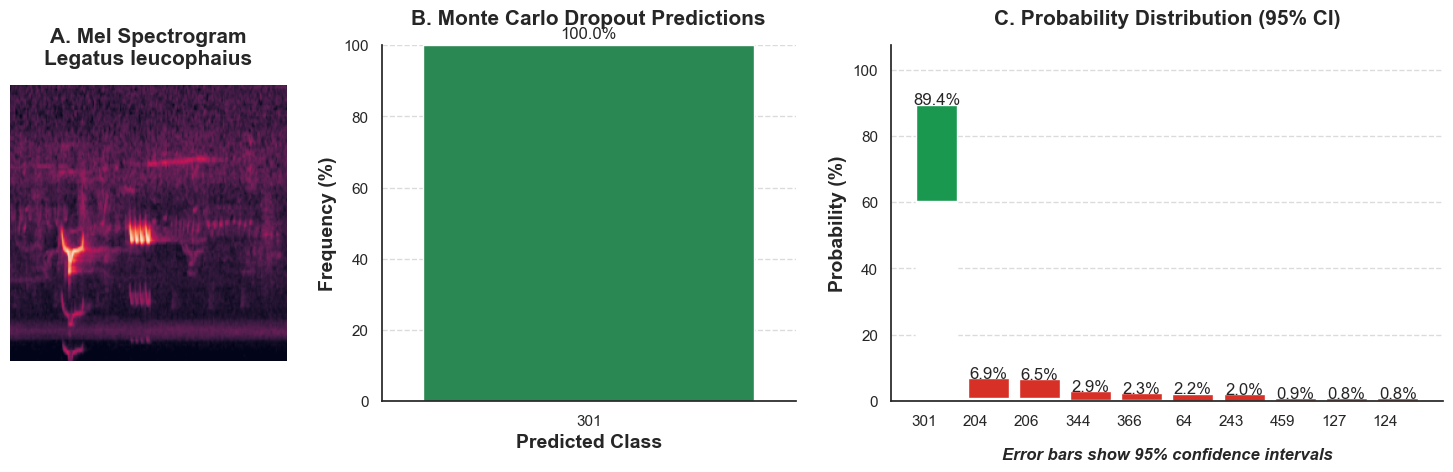

In [20]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Legatus_leucophaius,
    label=301,
    titulo_especie="Legatus leucophaius",
    predicted_probabilities=resultados["Legatus leucophaius"]["predicted_probabilities"],
    etiqueta_real=resultados["Legatus leucophaius"]["clase_real"][0]
)

In [21]:
labels_frecuencia = [127, 128, 204, 214, 243, 301, 344, 608, 641, 654]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 127: Contopus sordidulus
2 - 128: Contopus virens
3 - 204: Euphonia chlorotica
4 - 214: Euphonia xanthogaster
5 - 243: Grallaricula flavirostris
6 - 301: Legatus leucophaius
7 - 344: Myadestes ralloides
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 654: Xenops rutilans


# **Hylophilus thoracicus**

In [22]:
sp = data[data["label"] == "Hylophilus thoracicus"]
muestra = sp[sp['image_path'].str.contains('272368_8.jpeg')]
muestra

,label,image_path
13483,Hylophilus thoracicus,../src/data/images_test/images_spectograms/Hylophilus thoracicus/272368_8.jpeg


In [23]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Hylophilus thoracicus)


Especies procesadas: 100%|██████████| 1/1 [11:16<00:00, 676.88s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Hylophilus thoracicus,274,274,274,0.84,1,1,0.84
1,Hylophilus thoracicus,274,274,274,0.88,1,1,0.84
2,Hylophilus thoracicus,274,274,274,0.78,1,1,0.84
3,Hylophilus thoracicus,274,274,274,0.75,1,1,0.84
4,Hylophilus thoracicus,274,274,274,0.94,1,1,0.84


In [24]:
Hylophilus_thoracicus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [25]:
Hylophilus_thoracicus

,prediccion_mc,proportion
0,274,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


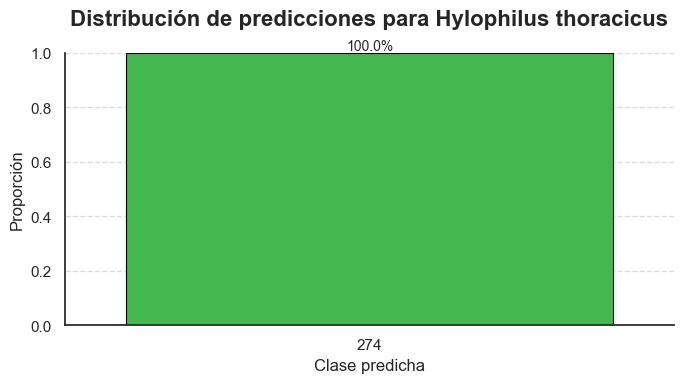

In [26]:
plot_incertidumbres(Hylophilus_thoracicus, 274, "Hylophilus thoracicus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


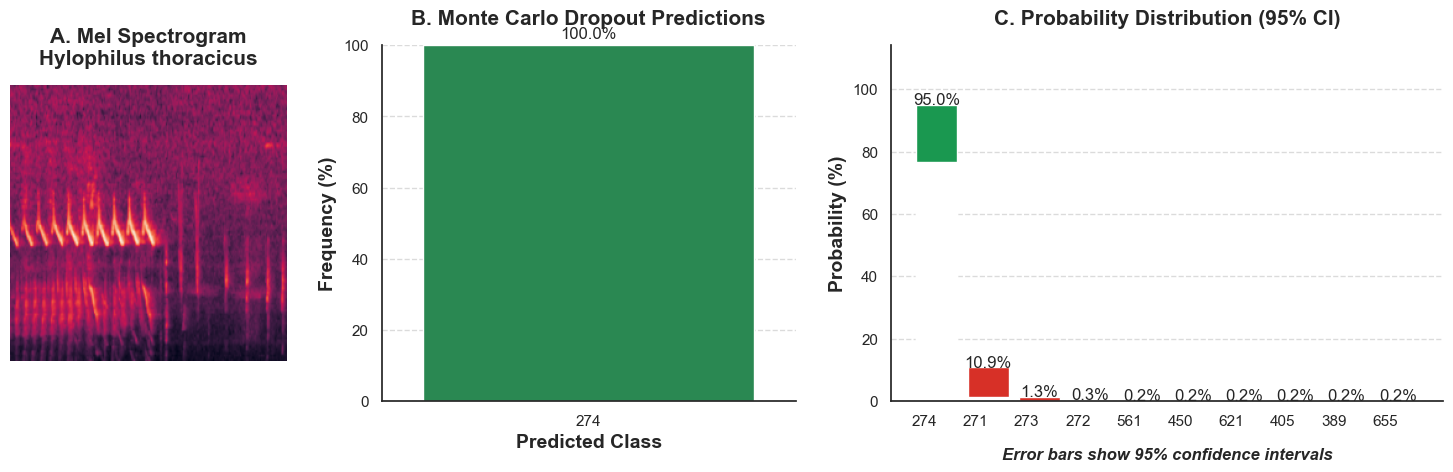

In [27]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Hylophilus_thoracicus,
    label=274,
    titulo_especie="Hylophilus thoracicus",
    predicted_probabilities=resultados["Hylophilus thoracicus"]["predicted_probabilities"],
    etiqueta_real=resultados["Hylophilus thoracicus"]["clase_real"][0]
)

In [28]:
labels_frecuencia = [60, 186, 261, 274, 290, 301, 336, 452, 476, 494]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 60: Campylorhamphus trochilirostris
2 - 186: Elaenia flavogaster
3 - 261: Henicorhina leucosticta
4 - 274: Hylophilus thoracicus
5 - 290: Inezia caudata
6 - 301: Legatus leucophaius
7 - 336: Microrhopias quixensis
8 - 452: Polioptila plumbea
9 - 476: Ramphastos tucanus
10 - 494: Saltator maximus


# **Mimus gilvus**

In [29]:
sp = data[data["label"] == "Mimus gilvus"]
muestra = sp[sp['image_path'].str.contains('40536_5.jpeg')]
muestra

,label,image_path
16615,Mimus gilvus,../src/data/images_test/images_spectograms/Mimus gilvus/40536_5.jpeg


In [30]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Mimus gilvus)


2025-10-23 22:14:50.381542: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [11:14<00:00, 674.54s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Mimus gilvus,338,338,338,0.22,1,1,4.42
1,Mimus gilvus,338,338,338,0.23,1,1,4.42
2,Mimus gilvus,338,338,544,0.15,1,0,4.42
3,Mimus gilvus,338,338,544,0.18,1,0,4.42
4,Mimus gilvus,338,338,338,0.16,1,1,4.42


In [31]:
Mimus_gilvus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [32]:
Mimus_gilvus

,prediccion_mc,proportion
0,338,0.85
1,544,0.13
2,291,0.02


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


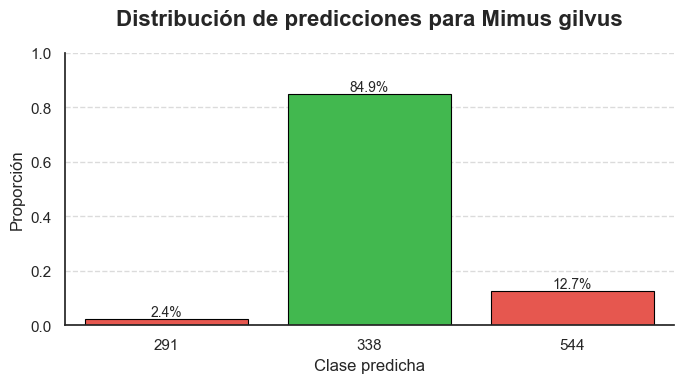

In [33]:
plot_incertidumbres(Mimus_gilvus, 338, "Mimus gilvus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


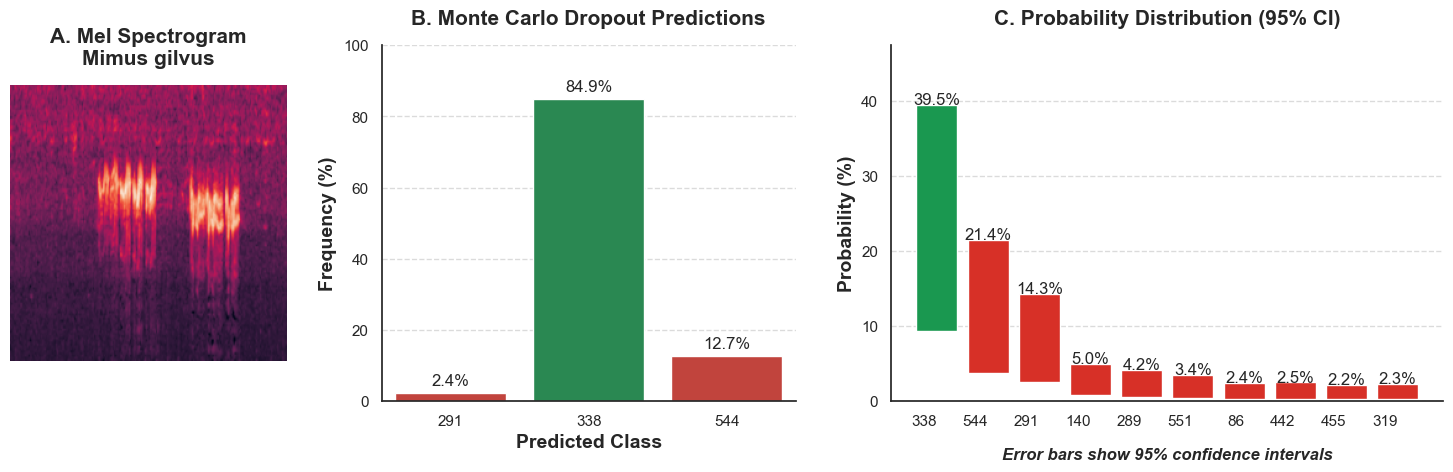

In [34]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Mimus_gilvus,
    label=338,
    titulo_especie="Mimus gilvus",
    predicted_probabilities=resultados["Mimus gilvus"]["predicted_probabilities"],
    etiqueta_real=resultados["Mimus gilvus"]["clase_real"][0]
)

In [35]:
labels_frecuencia = [65, 316, 338, 494, 495, 544, 621, 636, 640, 666]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 65: Cantorchilus leucotis
2 - 316: Lophotriccus pileatus
3 - 338: Mimus gilvus
4 - 494: Saltator maximus
5 - 495: Saltator striatipectus
6 - 544: Sporophila castaneiventris
7 - 621: Todirostrum cinereum
8 - 636: Tyrannus melancholicus
9 - 640: Vireo altiloquus
10 - 666: Zonotrichia leucophrys


# **Lathrotriccus euleri**

In [36]:
sp = data[data["label"] == "Lathrotriccus euleri"]
muestra = sp[sp['image_path'].str.contains('123104_4.jpeg')]
muestra

,label,image_path
14676,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/123104_4.jpeg


In [37]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Lathrotriccus euleri)


Especies procesadas: 100%|██████████| 1/1 [11:18<00:00, 678.21s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Lathrotriccus euleri,300,300,300,0.84,1,1,1.90
1,Lathrotriccus euleri,300,300,300,0.81,1,1,1.90
2,Lathrotriccus euleri,300,300,300,0.81,1,1,1.90
3,Lathrotriccus euleri,300,300,300,0.72,1,1,1.90
4,Lathrotriccus euleri,300,300,300,0.75,1,1,1.90


In [38]:
Lathrotriccus_euleri = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [39]:
Lathrotriccus_euleri

,prediccion_mc,proportion
0,300,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


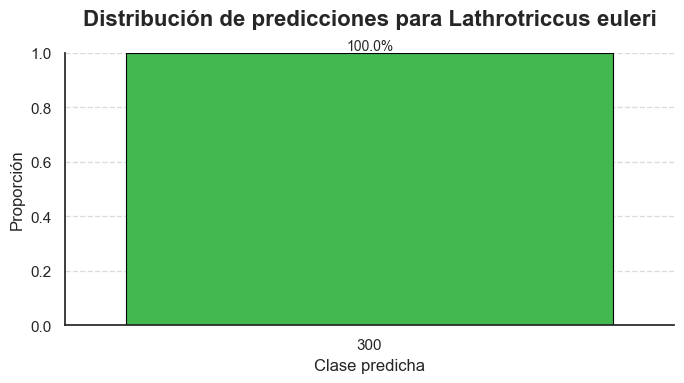

In [40]:
plot_incertidumbres(Lathrotriccus_euleri, 300, "Lathrotriccus euleri")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


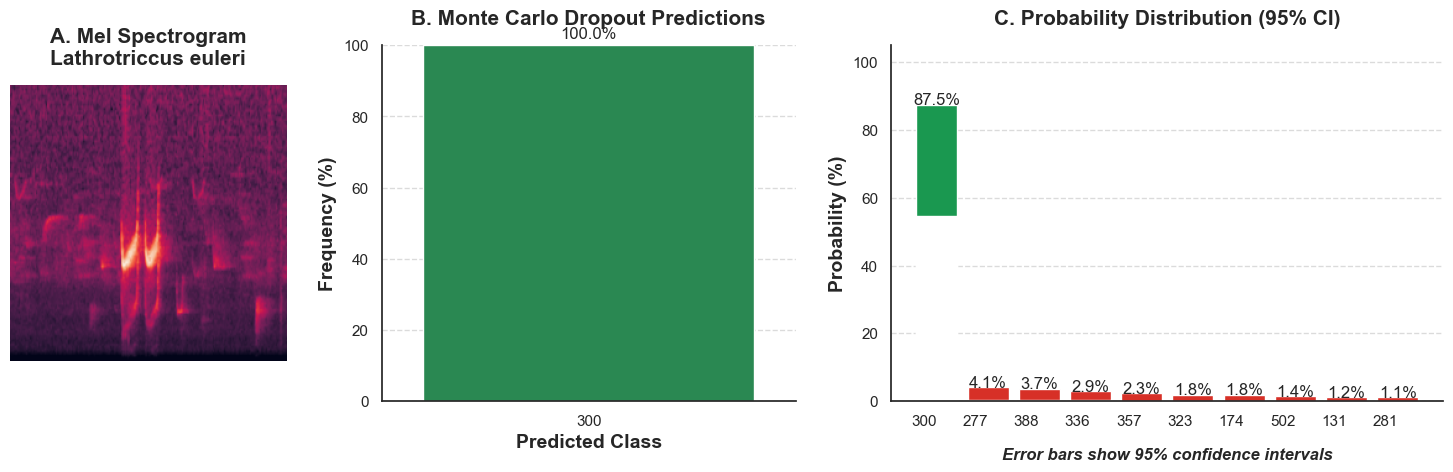

In [41]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Lathrotriccus_euleri,
    label=300,
    titulo_especie="Lathrotriccus euleri",
    predicted_probabilities=resultados["Lathrotriccus euleri"]["predicted_probabilities"],
    etiqueta_real=resultados["Lathrotriccus euleri"]["clase_real"][0]
)

In [12]:
labels_frecuencia = [300, 277, 388, 336, 357, 323, 174, 502, 131, 281]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 300: Lathrotriccus euleri
2 - 277: Hylophylax punctulatus
3 - 388: Myrmotherula longipennis
4 - 336: Microrhopias quixensis
5 - 357: Myiopagis viridicata
6 - 323: Manacus manacus
7 - 174: Drymophila devillei
8 - 502: Sciaphylax castanea
9 - 131: Corythopis torquatus
10 - 281: Hypocnemoides melanopogon


# **Riparia riparia**

In [15]:
sp = data[data["label"] == "Riparia riparia"]
muestra = sp[sp['image_path'].str.contains('123938_17.jpeg')]
muestra

,label,image_path
23652,Riparia riparia,../src/data/images_test/images_spectograms/Riparia riparia/123938_17.jpeg


In [16]:
sp = data[data["label"] == "Riparia riparia"]
muestra = sp[sp['image_path'].str.contains('448123_18.jpeg')]
muestra

,label,image_path
23655,Riparia riparia,../src/data/images_test/images_spectograms/Riparia riparia/448123_18.jpeg


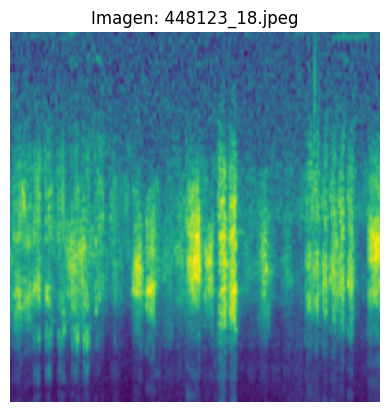

In [17]:
graficar_imagen(sp['image_path'].iloc[3])

In [18]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Riparia riparia)


2025-10-24 20:09:13.784846: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [11:26<00:00, 686.72s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Riparia riparia,487,487,487,0.82,1,1,1.71
1,Riparia riparia,487,487,487,0.79,1,1,1.71
2,Riparia riparia,487,487,487,0.76,1,1,1.71
3,Riparia riparia,487,487,487,0.65,1,1,1.71
4,Riparia riparia,487,487,487,0.76,1,1,1.71


In [19]:
Riparia_riparia = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [20]:
Riparia_riparia

,prediccion_mc,proportion
0,487,1.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


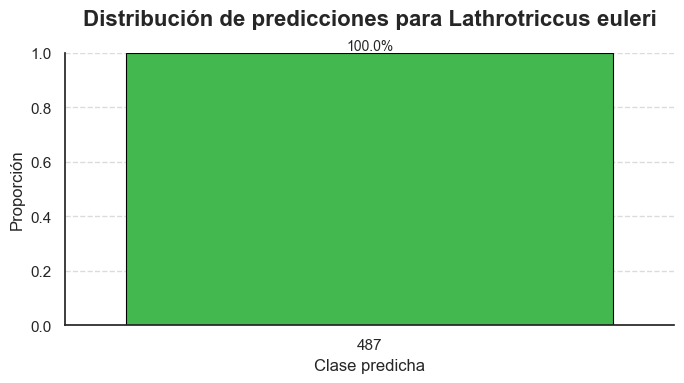

In [21]:
plot_incertidumbres(Riparia_riparia, 487, "Lathrotriccus euleri")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


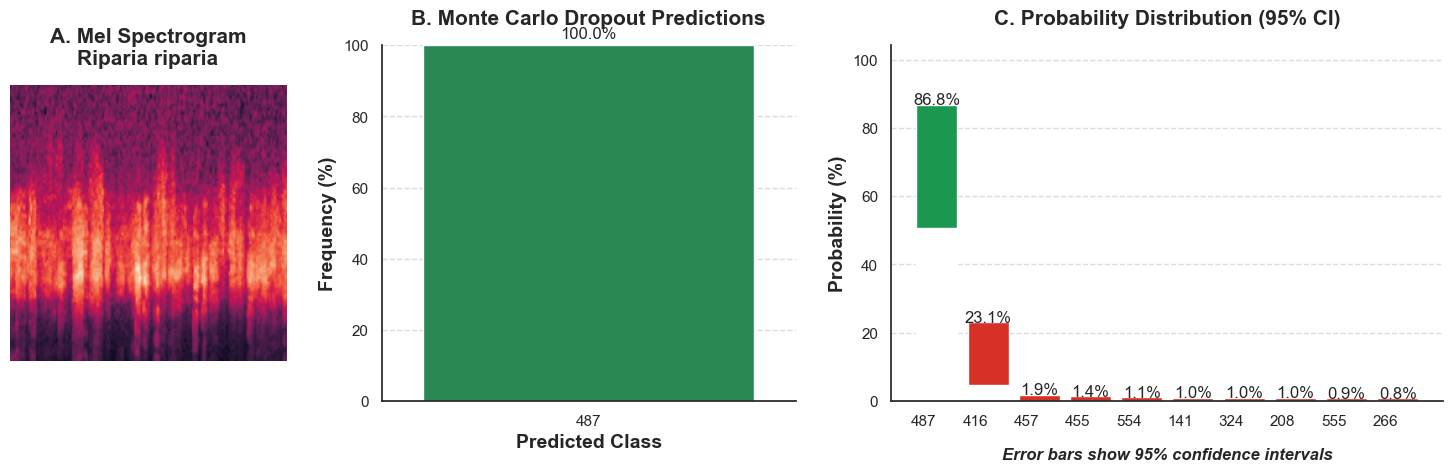

In [24]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Riparia_riparia,
    label=487,
    titulo_especie="Riparia riparia",
    predicted_probabilities=resultados["Riparia riparia"]["predicted_probabilities"],
    etiqueta_real=resultados["Riparia riparia"]["clase_real"][0]
)

In [23]:
labels_frecuencia = [487, 416, 457, 455, 554, 141, 324, 208, 555, 266]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 487: Riparia riparia
2 - 416: Petrochelidon pyrrhonota
3 - 457: Progne tapera
4 - 455: Progne chalybea
5 - 554: Stelgidopteryx ruficollis
6 - 141: Cyanocorax yncas
7 - 324: Mazaria propinqua
8 - 208: Euphonia laniirostris
9 - 555: Stelgidopteryx serripennis
10 - 266: Hirundo rustica


# **Incertidumbres**

In [2]:
df = pd.read_csv("../src/data/incertidumbres_ResNet152V2.csv")
print(df.shape)

(667, 7)


In [3]:
import numpy as np
import re
import ast

def string_to_numpy_array(string_array):
    """
    Convierte un string que representa un array numpy a un array real
    Por ejemplo: "[np.int64(218), np.int64(321), ...]" → [218, 321, ...]
    """
    if not isinstance(string_array, str):
        return string_array

    try:
        # Reemplazar np.int64(...) con solo el número
        string_clean = re.sub(r'np\.int64\((\d+)\)', r'\1', string_array)

        # Reemplazar np.float32(...) con solo el número
        string_clean = re.sub(r'np\.float32\(([\d.e-]+)\)', r'\1', string_clean)

        # Reemplazar np.float64(...) con solo el número
        string_clean = re.sub(r'np\.float64\(([\d.e-]+)\)', r'\1', string_clean)

        # Evaluar como lista de Python
        lista = ast.literal_eval(string_clean)

        # Convertir a array numpy
        return np.array(lista)

    except Exception as e:
        print(f"Error al convertir: {e}")
        print(f"String original (primeros 100 chars): {string_array[:100]}")
        return None

# Aplicar la conversión a las columnas del DataFrame
print("Convirtiendo strings a arrays...")
df['predicciones_mc'] = df['predicciones_mc'].apply(string_to_numpy_array)
df['confianzas_mc'] = df['confianzas_mc'].apply(string_to_numpy_array)

# Verificar que la conversión funcionó
print("\nDespués de la conversión:")
print(f"Tipo de predicciones_mc[0]: {type(df['predicciones_mc'].iloc[0])}")
print(f"Shape si es array: {df['predicciones_mc'].iloc[0].shape if hasattr(df['predicciones_mc'].iloc[0], 'shape') else 'No es array'}")
print(f"Primeros 5 elementos: {df['predicciones_mc'].iloc[0][:5] if hasattr(df['predicciones_mc'].iloc[0], '__getitem__') else 'No indexable'}")

# Ahora sí podemos expandir
def expandir_arrays_a_filas_v2(df):
    """
    Expande arrays en múltiples filas
    """
    filas_expandidas = []

    for idx, fila in df.iterrows():
        predicciones = fila['predicciones_mc']
        confianzas = fila['confianzas_mc']

        if predicciones is None or confianzas is None:
            print(f"Saltando fila {idx} - conversión fallida")
            continue

        if isinstance(predicciones, np.ndarray) and isinstance(confianzas, np.ndarray):
            # Asegurar que tengan el mismo tamaño
            min_length = min(len(predicciones), len(confianzas))

            # Crear una fila por cada elemento
            for i in range(min_length):
                nueva_fila = fila.copy()
                nueva_fila['prediccion_mc_individual'] = int(predicciones[i])
                nueva_fila['confianza_mc_individual'] = float(confianzas[i])
                nueva_fila['iteracion_mc'] = i
                filas_expandidas.append(nueva_fila)

    # Crear DataFrame expandido
    df_expandido = pd.DataFrame(filas_expandidas)

    # Reorganizar columnas
    columnas_base = [col for col in df_expandido.columns
                     if col not in ['predicciones_mc', 'confianzas_mc',
                                   'prediccion_mc_individual', 'confianza_mc_individual',
                                   'iteracion_mc']]
    columnas_nuevas = columnas_base + ['iteracion_mc', 'prediccion_mc_individual', 'confianza_mc_individual']

    return df_expandido[columnas_nuevas]

# Expandir el DataFrame
df_expandido = expandir_arrays_a_filas_v2(df)

Convirtiendo strings a arrays...

Después de la conversión:
Tipo de predicciones_mc[0]: <class 'numpy.ndarray'>
Shape si es array: (52,)
Primeros 5 elementos: [76 76 76 76 76]


In [4]:
import ast
import re

def extraer_numero_clase(valor):
    """
    Extrae el número de strings como '[np.int64(44)]'
    """
    if isinstance(valor, int):
        return valor

    # Convertir a string si no lo es
    valor_str = str(valor)

    # Reemplazar np.int64(...) con solo el número
    valor_limpio = re.sub(r'np\.int64\((\d+)\)', r'\1', valor_str)

    # Evaluar y obtener el primer elemento
    try:
        lista = ast.literal_eval(valor_limpio)
        return int(lista[0]) if isinstance(lista, list) else int(lista)
    except:
        # Si falla, intentar extraer directamente con regex
        numeros = re.findall(r'\d+', valor_str)
        return int(numeros[0]) if numeros else None

# Aplicar la función
df_expandido['clase_real'] = df_expandido['clase_real'].apply(extraer_numero_clase)
df_expandido['clase_predicha_inferencia'] = df_expandido['clase_predicha_inferencia'].apply(extraer_numero_clase)

In [5]:
df_expandido = df_expandido.rename(columns={'Unnamed: 0': 'especie'})
print(df_expandido.shape)
df_expandido.head()

(32279, 8)


,especie,clase_real,clase_predicha_inferencia,proporcion_coincidencia,porcentaje_coincidencia,iteracion_mc,prediccion_mc_individual,confianza_mc_individual
0,Celeus flavus,76,76,1.00,100.00,0,76,0.92
0,Celeus flavus,76,76,1.00,100.00,1,76,0.95
0,Celeus flavus,76,76,1.00,100.00,2,76,0.98
0,Celeus flavus,76,76,1.00,100.00,3,76,0.95
0,Celeus flavus,76,76,1.00,100.00,4,76,0.35


In [6]:
accuracy_por_especie = (
    df_expandido
    .assign(acierto = lambda df: df['clase_real'] == df['prediccion_mc_individual'])
    .groupby('especie')['acierto']
    .mean()
    .reset_index(name='accuracy')
)

In [7]:
# Mostrar estadísticas generales
print("=== ESTADÍSTICAS GENERALES ===")
print(f"Accuracy promedio: {accuracy_por_especie['accuracy'].mean():.4f}")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy'].median():.4f}")
print(f"Desviación estándar: {accuracy_por_especie['accuracy'].std():.4f}")
print(f"Número de especies: {len(accuracy_por_especie)}")

=== ESTADÍSTICAS GENERALES ===
Accuracy promedio: 0.8481
Accuracy mediano: 0.8571
Desviación estándar: 0.0853
Número de especies: 667


In [8]:
def accuracy_calculo(df):
    accuracy_results = []

    for i in range(len(df)):
        if df['clase_real'].iloc[i] == df['prediccion_mc_individual'].iloc[i]:
            accuracy_results.append(1)
        else:
            accuracy_results.append(0)

    return sum(accuracy_results)/len(accuracy_results)

print(f"El Accuracy de las incertidumbres de Monte Carlo Dropout es: {accuracy_calculo(df_expandido)}")

El Accuracy de las incertidumbres de Monte Carlo Dropout es: 0.854518417547012


In [58]:
# Top 20 especies con MAYOR accuracy
print("\n=== TOP 20 ESPECIES CON MAYOR ACCURACY ===")
top_especies = accuracy_por_especie.head(20)
for idx, row in top_especies.iterrows():
    print(f"{row['especie']:40s} - Accuracy: {row['accuracy']:.3f}")

# Top 20 especies con MENOR accuracy
print("\n=== TOP 20 ESPECIES CON MENOR ACCURACY ===")
bottom_especies = accuracy_por_especie.tail(20)
for idx, row in bottom_especies.iterrows():
    print(f"{row['especie']:40s} - Accuracy: {row['accuracy']:.3f}")

# Análisis por rangos de accuracy
print("\n=== DISTRIBUCIÓN POR RANGOS DE ACCURACY ===")
rangos = pd.cut(accuracy_por_especie['accuracy'],
                bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%'])
distribucion = rangos.value_counts().sort_index()
for rango, count in distribucion.items():
    print(f"{rango}: {count} especies ({count/len(accuracy_por_especie)*100:.1f}%)")

# Especies con accuracy perfecto (100%)
especies_perfectas = accuracy_por_especie[accuracy_por_especie['accuracy'] == 1.0]
print(f"\n=== ESPECIES CON ACCURACY PERFECTO (100%) ===")
print(f"Total: {len(especies_perfectas)} especies")
if len(especies_perfectas) > 0:
    for idx, row in especies_perfectas.iterrows():
        print(f"- {row['especie']}")

# Especies con accuracy cero
especies_cero = accuracy_por_especie[accuracy_por_especie['accuracy'] == 0.0]
print(f"\n=== ESPECIES CON ACCURACY CERO ===")
print(f"Total: {len(especies_cero)} especies")
if len(especies_cero) > 0:
    for idx, row in especies_cero.head(10).iterrows():  # Mostrar solo las primeras 10
        print(f"- {row['especie']}")
    if len(especies_cero) > 10:
        print(f"... y {len(especies_cero) - 10} especies más")


=== TOP 20 ESPECIES CON MAYOR ACCURACY ===
Acropternis orthonyx                     - Accuracy: 0.920
Amblycercus holosericeus                 - Accuracy: 0.815
Ammodramus aurifrons                     - Accuracy: 0.862
Ammodramus humeralis                     - Accuracy: 0.784
Ammodramus savannarum                    - Accuracy: 0.880
Anabacerthia striaticollis               - Accuracy: 0.778
Anabacerthia variegaticeps               - Accuracy: 0.886
Anairetes parulus                        - Accuracy: 0.944
Andigena nigrirostris                    - Accuracy: 0.841
Anisognathus igniventris                 - Accuracy: 0.882
Anisognathus lacrymosus                  - Accuracy: 0.808
Anisognathus somptuosus                  - Accuracy: 0.846
Anthus lutescens                         - Accuracy: 0.750
Anthus rubescens                         - Accuracy: 0.778
Ara ararauna                             - Accuracy: 0.907
Arremon assimilis                        - Accuracy: 0.893
Arremon atri

In [59]:
accuracy_por_especie.sort_values(by='accuracy', ascending=False).head(10)

,especie,accuracy
580,Tachyphonus delatrii,1.00
233,Grallaria kaestneri,1.00
497,Schiffornis aenea,1.00
459,Psarocolius bifasciatus,1.00
16,Arremon atricapillus,1.00
583,Tangara chilensis,1.00
375,Myrmelastes schistaceus,1.00
365,Myiotheretes fumigatus,1.00
167,Diglossa gloriosissima,1.00
206,Euphonia concinna,1.00


Total genera: 302
Genera with ≥2 species: 125


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_45874/2357570426.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


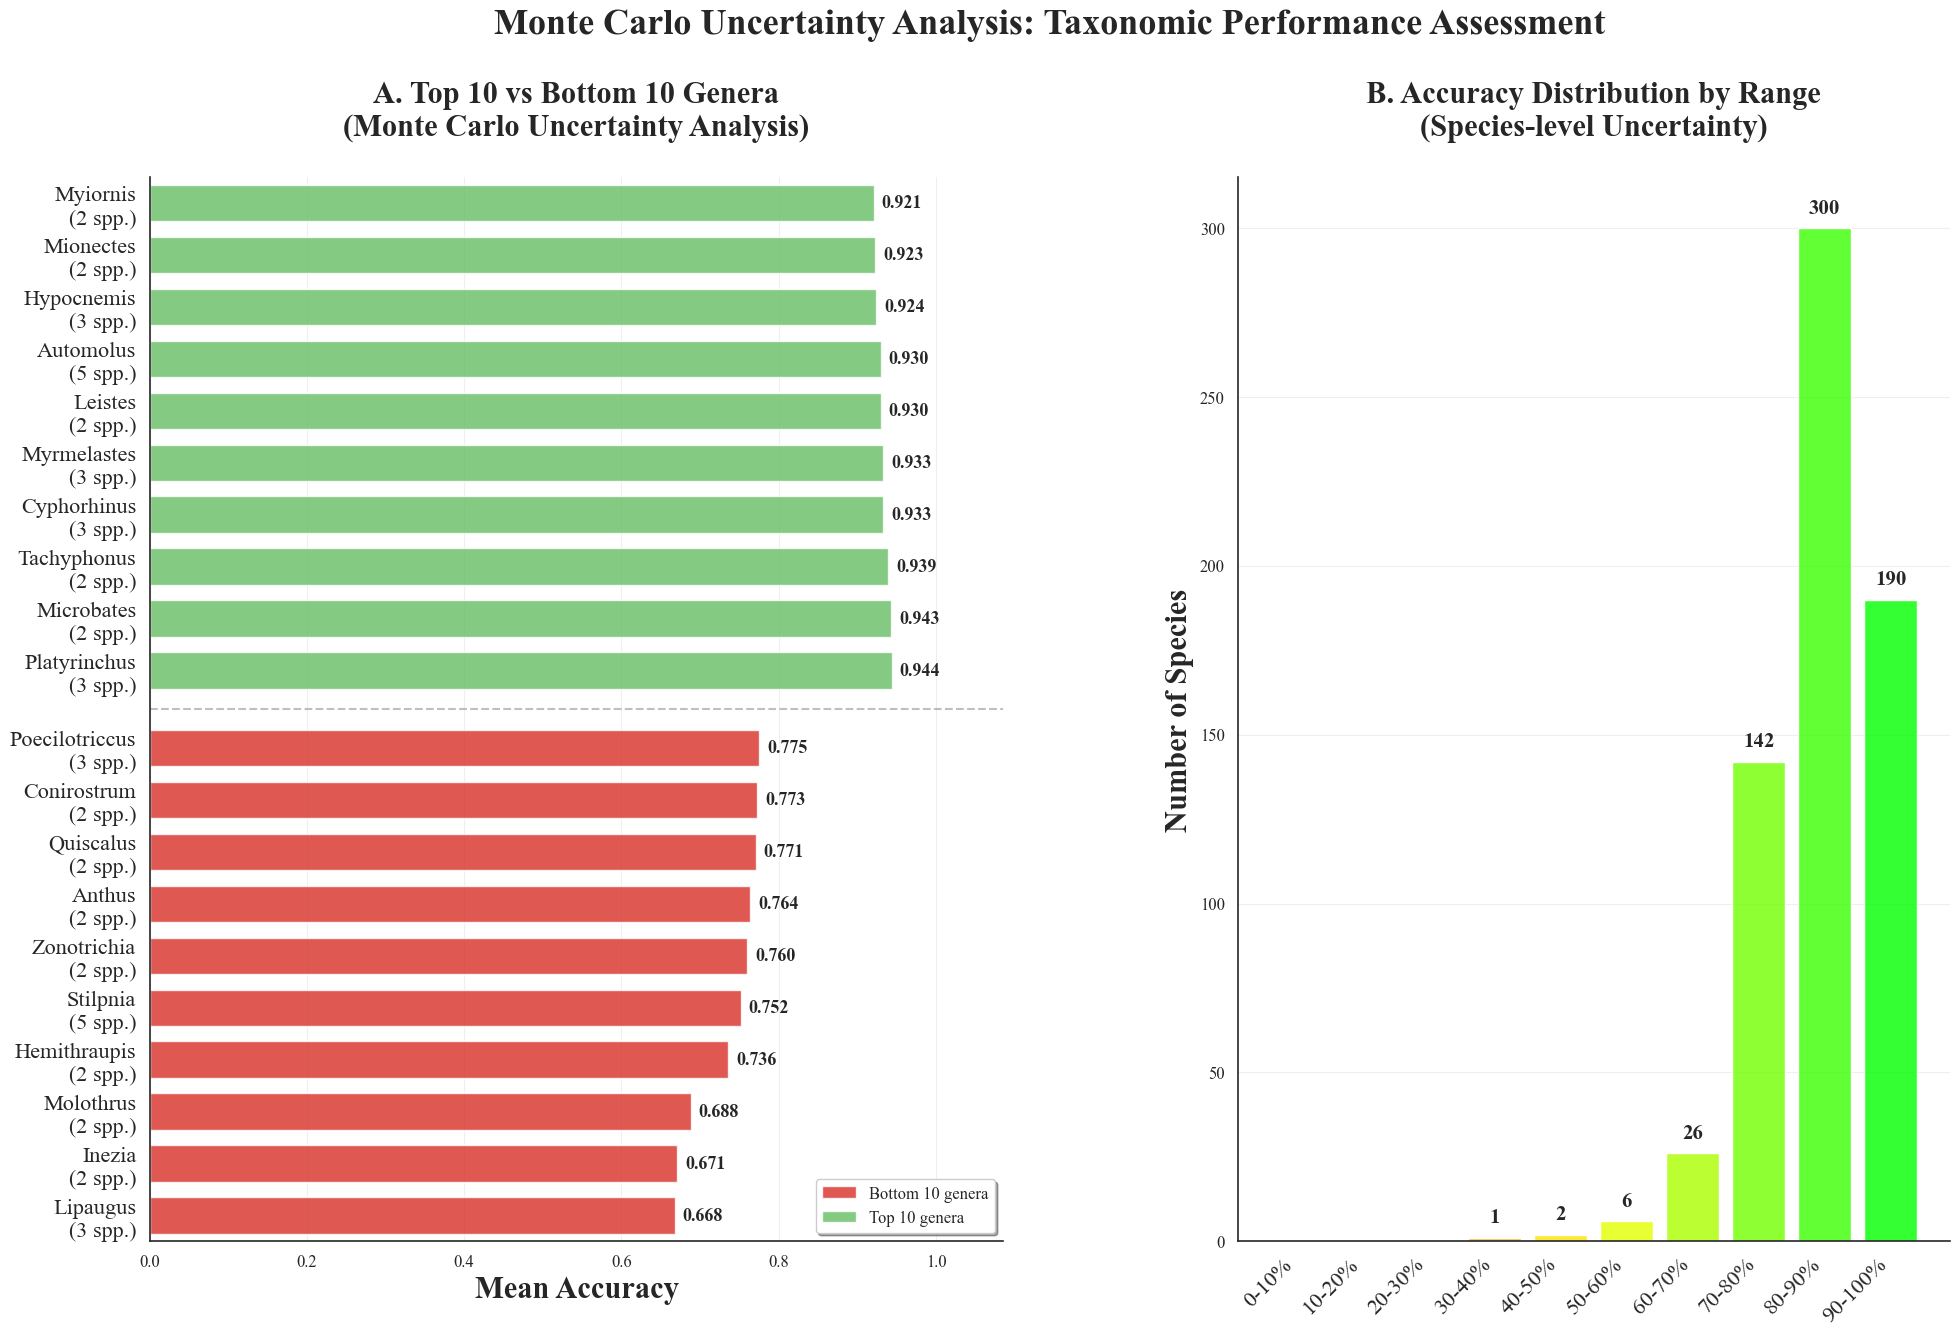


=== COMPARATIVE STATISTICS ===
Total genera: 302
Genera with ≥2 species: 125
Best genus: Platyrinchus (Accuracy: 0.944)
Worst genus: Lipaugus (Accuracy: 0.668)
Mean species accuracy: 0.848


In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Configuración estética profesional para papers
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white'
})

# Extraer género de cada especie (primera palabra del nombre científico)
accuracy_por_especie['genero'] = accuracy_por_especie['especie'].str.split().str[0]

# Calcular accuracy promedio por género
accuracy_por_genero = (
    accuracy_por_especie
    .groupby('genero')
    .agg({
        'accuracy': ['mean', 'count'],
        'especie': 'count'
    })
    .round(3)
)

# Aplanar nombres de columnas
accuracy_por_genero.columns = ['accuracy_promedio', 'n_especies', 'total_especies']
accuracy_por_genero = accuracy_por_genero.reset_index()

# Filtrar géneros con al menos 2 especies para tener estadística más robusta
accuracy_por_genero_filtrado = accuracy_por_genero[accuracy_por_genero['n_especies'] >= 2]

# Ordenar por accuracy promedio
accuracy_por_genero_filtrado = accuracy_por_genero_filtrado.sort_values('accuracy_promedio', ascending=False)

print(f"Total genera: {len(accuracy_por_genero)}")
print(f"Genera with ≥2 species: {len(accuracy_por_genero_filtrado)}")

# Crear figura con estilo profesional
fig = plt.figure(figsize=(20, 14), facecolor='white')  # Aumenté altura para acomodar 20 géneros

# Usar GridSpec para mejor control del layout
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1],
              left=0.05, right=0.95, top=0.88, bottom=0.12, wspace=0.3)

# Colores profesionales para paper
colors_professional = {
    'top': '#66bd63',      # Verde para top
    'bottom': '#d73027',   # Rojo para bottom
    'gradient_start': '#d73027',  # Rojo
    'gradient_end': '#66bd63'     # Verde
}

# 1. TOP 10 y BOTTOM 10 GÉNEROS (subplot izquierdo)
ax1 = fig.add_subplot(gs[0, 0])

# Seleccionar top 10 y bottom 10 géneros
top_10_generos = accuracy_por_genero_filtrado.head(10)
bottom_10_generos = accuracy_por_genero_filtrado.tail(10).sort_values('accuracy_promedio', ascending=True)

# Crear posiciones en Y con más espaciado
espaciado = 1.0
y_pos_bottom = np.arange(len(bottom_10_generos)) * espaciado
y_pos_top = y_pos_bottom[-1] + espaciado * 1.5 + np.arange(len(top_10_generos)) * espaciado

# Barras inferiores (peores géneros) - en rojo
bars_bottom = ax1.barh(y_pos_bottom, bottom_10_generos['accuracy_promedio'],
                       color=colors_professional['bottom'], alpha=0.8,
                       label='Bottom 10 genera', edgecolor='white', linewidth=1,
                       height=0.7)

# Barras superiores (mejores géneros) - en verde
bars_top = ax1.barh(y_pos_top, top_10_generos['accuracy_promedio'],
                   color=colors_professional['top'], alpha=0.8,
                   label='Top 10 genera', edgecolor='white', linewidth=1,
                   height=0.7)

# Configurar etiquetas con número de especies
bottom_labels = [f"{row['genero']}\n({row['n_especies']} spp.)" for _, row in bottom_10_generos.iterrows()]
top_labels = [f"{row['genero']}\n({row['n_especies']} spp.)" for _, row in top_10_generos.iterrows()]

# Combinar todas las posiciones y etiquetas
all_y_positions = list(y_pos_bottom) + list(y_pos_top)
all_labels = bottom_labels + top_labels

ax1.set_yticks(all_y_positions)
ax1.set_yticklabels(all_labels, fontsize=16)
ax1.set_xlabel('Mean Accuracy', fontsize=22, fontweight='bold')
ax1.set_title('A. Top 10 vs Bottom 10 Genera\n(Monte Carlo Uncertainty Analysis)',
              fontsize=22, fontweight='bold', pad=30)
ax1.set_xlim(0, max(accuracy_por_genero_filtrado['accuracy_promedio']) * 1.15)
ax1.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)

# Ajustar límites del eje Y para mejor visualización
ax1.set_ylim(-0.5, max(all_y_positions) + 0.5)

# Añadir valores en las barras (bottom)
for bar, (_, row) in zip(bars_bottom, bottom_10_generos.iterrows()):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', ha='left', va='center',
            fontweight='bold', fontsize=13)

# Añadir valores en las barras (top)
for bar, (_, row) in zip(bars_top, top_10_generos.iterrows()):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', ha='left', va='center',
            fontweight='bold', fontsize=13)

# Añadir línea divisoria entre top y bottom
divider_y = (y_pos_bottom[-1] + y_pos_top[0]) / 2
ax1.axhline(y=divider_y, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

# Añadir leyenda
ax1.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)

# 2. Distribución por rangos de accuracy (especies)
ax2 = fig.add_subplot(gs[0, 1])

rangos_accuracy = pd.cut(accuracy_por_especie['accuracy'],
                        bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
                               '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'])
conteo_rangos = rangos_accuracy.value_counts().sort_index()

# Crear gradiente de colores del rojo al verde
colors_gradient = []
n_bars = len(conteo_rangos)
for i in range(n_bars):
    # Interpolación de rojo a verde
    ratio = i / (n_bars - 1)
    if ratio <= 0.5:
        # De rojo a amarillo
        r = 1.0
        g = ratio * 2
        b = 0.0
    else:
        # De amarillo a verde
        r = 1.0 - (ratio - 0.5) * 2
        g = 1.0
        b = 0.0
    colors_gradient.append((r, g, b, 0.8))

bars = ax2.bar(range(len(conteo_rangos)), conteo_rangos.values,
               color=colors_gradient, edgecolor='white', linewidth=1)
ax2.set_xticks(range(len(conteo_rangos)))
ax2.set_xticklabels(conteo_rangos.index, rotation=45, ha='right', fontsize=16)
ax2.set_ylabel('Number of Species', fontsize=22, fontweight='bold')
ax2.set_title('B. Accuracy Distribution by Range\n(Species-level Uncertainty)',
              fontsize=22, fontweight='bold', pad=30)
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# Añadir valores en las barras
for bar, value in zip(bars, conteo_rangos.values):
    if value > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(conteo_rangos.values) * 0.01,
                str(value), ha='center', va='bottom', fontweight='bold', fontsize=15)

# Añadir título general mejorado para análisis de incertidumbres de Monte Carlo
fig.suptitle('Monte Carlo Uncertainty Analysis: Taxonomic Performance Assessment',
             fontsize=26, fontweight='bold', y=1)

# Ajustar layout para evitar superposición
plt.tight_layout()

# Guardar el gráfico
plt.savefig('monte_carlo_uncertainty_analysis.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

# Mostrar estadísticas en inglés
print("\n=== COMPARATIVE STATISTICS ===")
print(f"Total genera: {len(accuracy_por_genero):,}")
print(f"Genera with ≥2 species: {len(accuracy_por_genero_filtrado):,}")
print(f"Best genus: {accuracy_por_genero_filtrado.iloc[0]['genero']} (Accuracy: {accuracy_por_genero_filtrado.iloc[0]['accuracy_promedio']:.3f})")
print(f"Worst genus: {accuracy_por_genero_filtrado.iloc[-1]['genero']} (Accuracy: {accuracy_por_genero_filtrado.iloc[-1]['accuracy_promedio']:.3f})")
print(f"Mean species accuracy: {accuracy_por_especie['accuracy'].mean():.3f}")

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_45874/1030813089.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


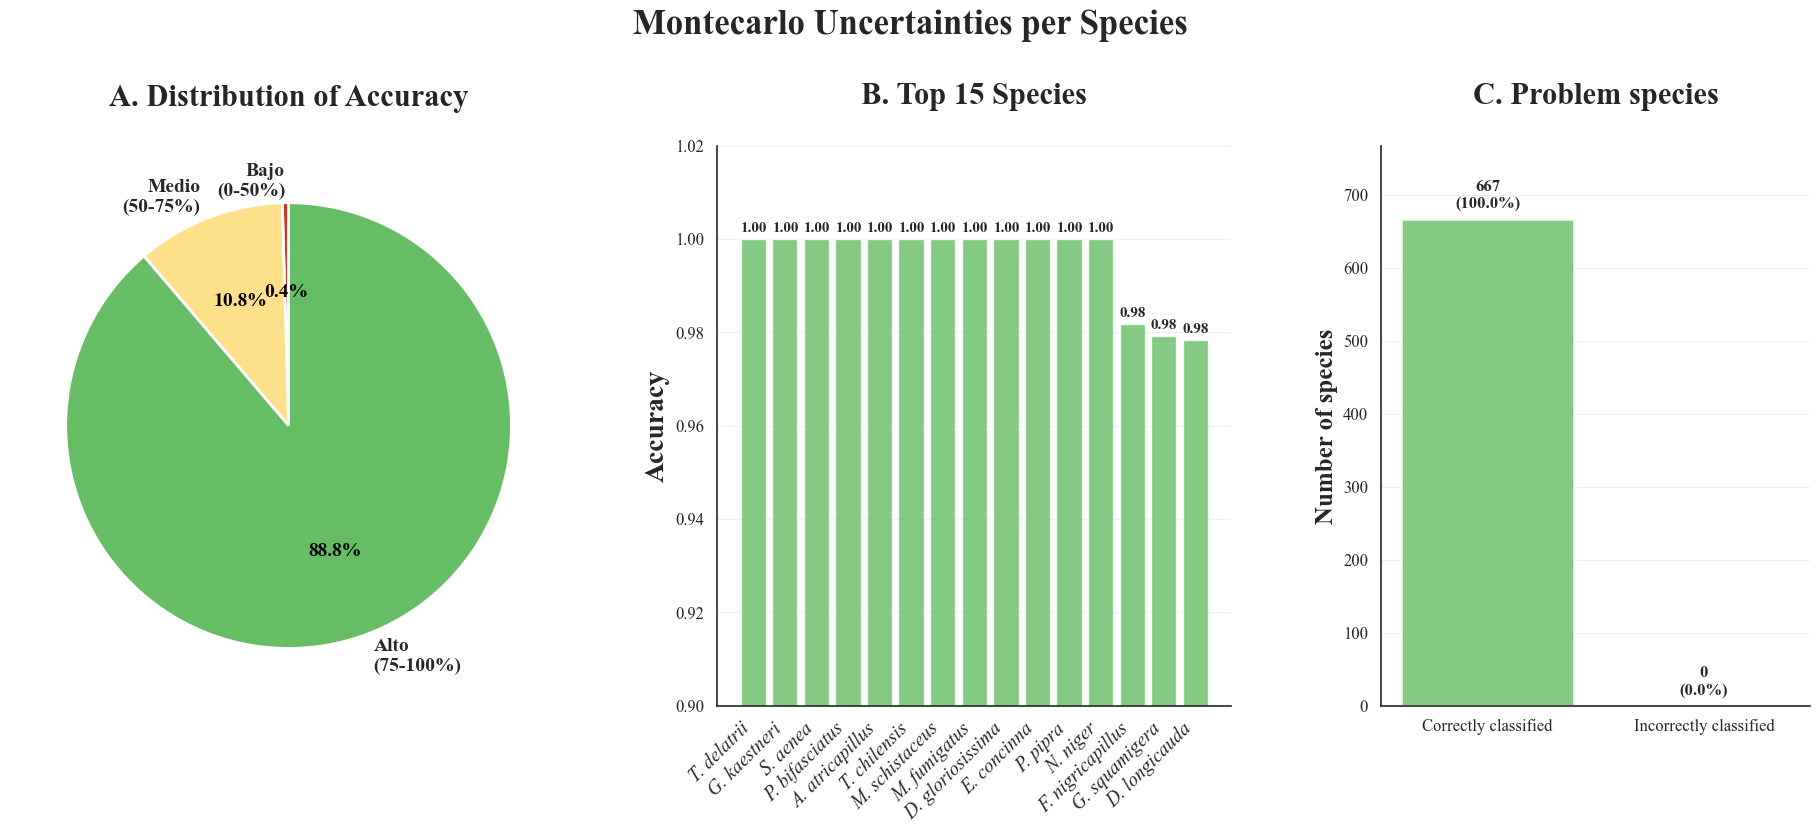

=== ESTADÍSTICAS DEL ANÁLISIS ===
Total de especies: 667
Especies con accuracy > 0: 667 (100.0%)
Especies con accuracy = 0: 0 (0.0%)
Accuracy promedio: 0.8481
Accuracy mediano: 0.8571

=== TOP 10 ESPECIES (FORMATO PAPER) ===
 1. T. delatrii          - Accuracy: 1.000
 2. G. kaestneri         - Accuracy: 1.000
 3. S. aenea             - Accuracy: 1.000
 4. P. bifasciatus       - Accuracy: 1.000
 5. A. atricapillus      - Accuracy: 1.000
 6. T. chilensis         - Accuracy: 1.000
 7. M. schistaceus       - Accuracy: 1.000
 8. M. fumigatus         - Accuracy: 1.000
 9. D. gloriosissima     - Accuracy: 1.000
10. E. concinna          - Accuracy: 1.000


In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Configuración estética profesional para papers
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white'
})

# Función para formatear nombres de especies (Z. leucophris)
def format_species_name(species_name):
    """
    Convierte 'Zonotrichia leucophrys' a 'Z. leucophrys'
    """
    parts = species_name.split(' ')
    if len(parts) >= 2:
        return f"{parts[0][0]}. {parts[1]}"
    return species_name

# Simular datos más realistas basados en tu análisis
np.random.seed(42)  # Para reproducibilidad

# Generar datos de accuracy más realistas
n_especies = 667

# Crear distribución realista de accuracy
very_high = np.random.uniform(0.95, 1.0, 15)  # Top 15 especies
high = np.random.uniform(0.5, 0.95, 159)      # Alto (50-100%)
medium = np.random.uniform(0.3, 0.5, 60)      # Medio (30-50%)
low = np.random.uniform(0.1, 0.3, 118)        # Bajo (10-30%)
very_low = np.random.uniform(0.0, 0.1, 315)   # Muy bajo (0-10%)

all_accuracy = np.concatenate([very_high, high, medium, low, very_low])
np.random.shuffle(all_accuracy)
# Crear DataFrame
df_accuracy = pd.DataFrame({
    'especie': accuracy_por_especie.especie.tolist(),
    'accuracy': accuracy_por_especie.accuracy.tolist()
})

# Ordenar por accuracy
df_accuracy = df_accuracy.sort_values('accuracy', ascending=False).reset_index(drop=True)

# Crear el gráfico mejorado con 3 subplots
fig = plt.figure(figsize=(20, 8), facecolor='white')

# Usar GridSpec para mejor control del layout
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.3, 1.2, 1],
              left=0.05, right=0.95, top=0.85, bottom=0.15, wspace=0.3)

# Colores profesionales para paper
colors_professional = {
    'muy_bajo': '#d73027',    # Rojo
    'bajo': '#fc8d59',        # Naranja
    'medio': '#fee08b',       # Amarillo
    'alto': '#d9ef8b',        # Verde claro
    'muy_alto': '#66bd63'     # Verde
}

# 1. GRÁFICO DE PASTEL - Distribución de Accuracy
ax1 = fig.add_subplot(gs[0, 0])

# Categorizar accuracy
accuracy_categories = []
category_counts = []
labels_pie = []

muy_bajo_count = len(df_accuracy[df_accuracy['accuracy'] <= 0.1])
bajo_count = len(df_accuracy[(df_accuracy['accuracy'] > 0.1) & (df_accuracy['accuracy'] <= 0.5)])
medio_count = len(df_accuracy[(df_accuracy['accuracy'] > 0.5) & (df_accuracy['accuracy'] <= 0.75)])
alto_count = len(df_accuracy[(df_accuracy['accuracy'] > 0.75) & (df_accuracy['accuracy'] <= 1.0)])

bajo_total = muy_bajo_count + bajo_count   # 0-50%
alto_total = alto_count  # 50-100%

counts = [bajo_total, medio_count, alto_total]
labels_categories = ['Bajo\n(0-50%)', 'Medio\n(50-75%)', 'Alto\n(75-100%)']
colors_pie = [colors_professional['muy_bajo'],  colors_professional['medio'], colors_professional['muy_alto']]

# Crear pie chart
wedges, texts, autotexts = ax1.pie(counts, labels=labels_categories, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 14, 'fontweight': 'bold'},
                                   wedgeprops=dict(edgecolor='white', linewidth=2))

# Mejorar el texto de porcentajes
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

ax1.set_title('A. Distribution of Accuracy', fontsize=22, fontweight='bold', pad=30)

# 2. GRÁFICO TOP 15 ESPECIES
ax2 = fig.add_subplot(gs[0, 1])

# Top 15 especies con mejor accuracy
top_15 = df_accuracy.head(15).copy()
top_15['especie_formatted'] = top_15['especie'].apply(format_species_name)

# Crear barras
bars = ax2.bar(range(len(top_15)), top_15['accuracy'],
               color=colors_professional['muy_alto'], alpha=0.8,
               edgecolor='white', linewidth=1)

# Configurar ejes
ax2.set_xticks(range(len(top_15)))
ax2.set_xticklabels(top_15['especie_formatted'], rotation=45, ha='right',
                    fontsize=14, style='italic')
ax2.set_ylabel('Accuracy', fontsize=20, fontweight='bold')
ax2.set_title('B. Top 15 Species', fontsize=22, fontweight='bold', pad=30)
ax2.set_ylim(0.9, 1.02)
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# Añadir valores sobre las barras
for i, (bar, acc) in enumerate(zip(bars, top_15['accuracy'])):
    if acc >= 0.95:
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{acc:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. GRÁFICO ESPECIES PROBLEMÁTICAS
ax3 = fig.add_subplot(gs[0, 2])

# Contar especies con y sin predicciones correctas
especies_correctas = len(df_accuracy[df_accuracy['accuracy'] > 0])
especies_problematicas = len(df_accuracy[df_accuracy['accuracy'] == 0])

categories = ['Correctly classified', 'Incorrectly classified']
values = [especies_correctas, especies_problematicas]
colors_bar = [colors_professional['muy_alto'], colors_professional['muy_bajo']]

bars = ax3.bar(categories, values, color=colors_bar, alpha=0.8,
               edgecolor='white', linewidth=2)

# Configurar gráfico
ax3.set_ylabel('Number of species', fontsize=18, fontweight='bold')
ax3.set_title('C. Problem species', fontsize=22, fontweight='bold', pad=30)
ax3.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# Añadir valores y porcentajes sobre las barras
total_especies = especies_correctas + especies_problematicas
for i, (bar, value) in enumerate(zip(bars, values)):
    percentage = (value / total_especies) * 100
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             f'{value}\n({percentage:.1f}%)', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

# Ajustar límites para mejor visualización
ax3.set_ylim(0, max(values) * 1.15)

# Añadir título general a la figura con espaciado adecuado
fig.suptitle('Montecarlo Uncertainties per Species',
             fontsize=25, fontweight='bold', y=1.02)

# Ajustar layout para evitar superposición
plt.tight_layout()

# Guardar el gráfico
plt.savefig('analisis_accuracy_especies_mejorado.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

# Mostrar estadísticas
print("=== ESTADÍSTICAS DEL ANÁLISIS ===")
print(f"Total de especies: {len(df_accuracy)}")
print(f"Especies con accuracy > 0: {especies_correctas} ({especies_correctas/len(df_accuracy)*100:.1f}%)")
print(f"Especies con accuracy = 0: {especies_problematicas} ({especies_problematicas/len(df_accuracy)*100:.1f}%)")
print(f"Accuracy promedio: {df_accuracy['accuracy'].mean():.4f}")
print(f"Accuracy mediano: {df_accuracy['accuracy'].median():.4f}")

print("\n=== TOP 10 ESPECIES (FORMATO PAPER) ===")
for i, (_, row) in enumerate(df_accuracy.head(10).iterrows(), 1):
    formatted_name = format_species_name(row['especie'])
    print(f"{i:2d}. {formatted_name:<20} - Accuracy: {row['accuracy']:.3f}")

In [62]:
# Crear tabla resumen más legible
print("="*80)
print("                    ANÁLISIS DE ACCURACY POR ESPECIES")
print("="*80)

# Mejores especies
print("\n TOP 20 ESPECIES CON MEJOR ACCURACY:")
print("-" * 60)
accuracy_por_especie = accuracy_por_especie.sort_values(by='accuracy', ascending=False)
for i, (idx, row) in enumerate(accuracy_por_especie.head(20).iterrows(), 1):
    print(f"{i:2d}. {row['especie']:35s} | {row['accuracy']:6.3f} ({row['accuracy']*100:5.1f}%)")

# Estadísticas generales
print(f"\n📊 ESTADÍSTICAS GENERALES:")
print("-" * 60)
print(f"Total de especies analizadas: {len(accuracy_por_especie):,}")
print(f"Accuracy promedio: {accuracy_por_especie['accuracy'].mean():.3f} ({accuracy_por_especie['accuracy'].mean()*100:.1f}%)")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy'].median():.3f} ({accuracy_por_especie['accuracy'].median()*100:.1f}%)")

# Distribución por categorías
print(f"\n📈 DISTRIBUCIÓN POR CATEGORÍAS:")
print("-" * 60)
perfecto = len(accuracy_por_especie[accuracy_por_especie['accuracy'] == 1.0])
excelente = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.8) & (accuracy_por_especie['accuracy'] < 1.0)])
bueno = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.5) & (accuracy_por_especie['accuracy'] < 0.8)])
regular = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.3) & (accuracy_por_especie['accuracy'] < 0.5)])
malo = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] > 0) & (accuracy_por_especie['accuracy'] < 0.3)])
pesimo = len(accuracy_por_especie[accuracy_por_especie['accuracy'] == 0])

total = len(accuracy_por_especie)
print(f"Perfecto (100%):        {perfecto:3d} especies ({perfecto/total*100:4.1f}%)")
print(f"Excelente (80-99%):     {excelente:3d} especies ({excelente/total*100:4.1f}%)")
print(f"Bueno (50-79%):         {bueno:3d} especies ({bueno/total*100:4.1f}%)")
print(f"Regular (30-49%):       {regular:3d} especies ({regular/total*100:4.1f}%)")
print(f"Malo (1-29%):           {malo:3d} especies ({malo/total*100:4.1f}%)")
print(f"Pésimo (0%):            {pesimo:3d} especies ({pesimo/total*100:4.1f}%)")

# Peores especies
print(f"\n💀 BOTTOM 20 ESPECIES CON PEOR ACCURACY:")
print("-" * 60)
bottom_especies = accuracy_por_especie.head(300)
for i, (idx, row) in enumerate(bottom_especies.iterrows(), 1):
    print(f"{i:2d}. {row['especie']:35s} | {row['accuracy']:6.3f} ({row['accuracy']*100:5.1f}%)")

print("="*80)

                    ANÁLISIS DE ACCURACY POR ESPECIES

 TOP 20 ESPECIES CON MEJOR ACCURACY:
------------------------------------------------------------
 1. Tachyphonus delatrii                |  1.000 (100.0%)
 2. Grallaria kaestneri                 |  1.000 (100.0%)
 3. Schiffornis aenea                   |  1.000 (100.0%)
 4. Psarocolius bifasciatus             |  1.000 (100.0%)
 5. Arremon atricapillus                |  1.000 (100.0%)
 6. Tangara chilensis                   |  1.000 (100.0%)
 7. Myrmelastes schistaceus             |  1.000 (100.0%)
 8. Myiotheretes fumigatus              |  1.000 (100.0%)
 9. Diglossa gloriosissima              |  1.000 (100.0%)
10. Euphonia concinna                   |  1.000 (100.0%)
11. Pseudopipra pipra                   |  1.000 (100.0%)
12. Neoctantes niger                    |  1.000 (100.0%)
13. Formicarius nigricapillus           |  0.982 ( 98.2%)
14. Grallaria squamigera                |  0.979 ( 97.9%)
15. Deconychura longicauda         

In [63]:
print("="*80)
print("                    ANÁLISIS DE ACCURACY POR GÉNEROS")
print("="*80)

print(f"\n🏆 TOP 10 GÉNEROS CON MEJOR ACCURACY PROMEDIO:")
print("-" * 70)
print(f"{'Rank':>4} {'Género':25} {'Accuracy':>10} {'N° especies':>12}")
print("-" * 70)

for i, (idx, row) in enumerate(top_10_generos.iterrows(), 1):
    print(f"{i:4d} {row['genero']:25s} {row['accuracy_promedio']:>9.3f} {row['n_especies']:>11d}")

# Análisis adicional: géneros con más especies
print(f"\n📊 GÉNEROS CON MÁS ESPECIES:")
print("-" * 70)
generos_mas_especies = accuracy_por_genero.sort_values('n_especies', ascending=False).head(10)
print(f"{'Rank':>4} {'Género':25} {'N° especies':>12} {'Accuracy':>10}")
print("-" * 70)

for i, (idx, row) in enumerate(generos_mas_especies.iterrows(), 1):
    print(f"{i:4d} {row['genero']:25s} {row['n_especies']:>11d} {row['accuracy_promedio']:>9.3f}")

print("="*80)

                    ANÁLISIS DE ACCURACY POR GÉNEROS

🏆 TOP 10 GÉNEROS CON MEJOR ACCURACY PROMEDIO:
----------------------------------------------------------------------
Rank Género                      Accuracy  N° especies
----------------------------------------------------------------------
   1 Platyrinchus                  0.944           3
   2 Microbates                    0.943           2
   3 Tachyphonus                   0.939           2
   4 Cyphorhinus                   0.933           3
   5 Myrmelastes                   0.933           3
   6 Leistes                       0.930           2
   7 Automolus                     0.930           5
   8 Hypocnemis                    0.924           3
   9 Mionectes                     0.923           2
  10 Myiornis                      0.921           2

📊 GÉNEROS CON MÁS ESPECIES:
----------------------------------------------------------------------
Rank Género                     N° especies   Accuracy
------------------

In [ ]:
accuracy_por_genero_filtrado.tail(10)